# **LISTA 03 AMA**

### Aluno: Jônatas Fernandes Silva
### Matrícula: 603243

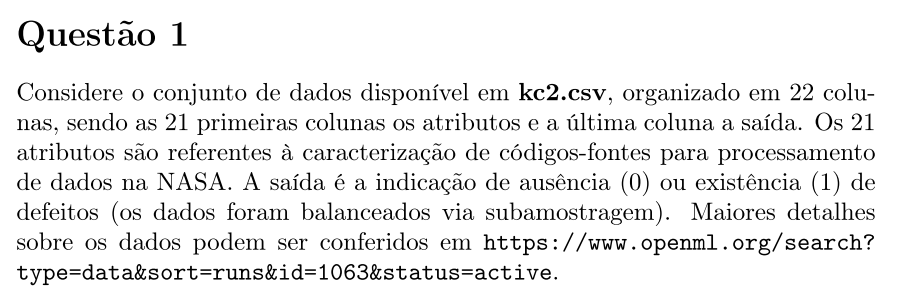

In [1]:
# Imports

import numpy as np
from sklearn.tree import DecisionTreeClassifier

In [2]:
# Montando o drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Carregar dados

dataset = np.genfromtxt('/content/kc2.csv', delimiter=',')
X = dataset[:, :-1]
y = dataset[:, -1].astype(int)

In [4]:
print("X:", X.shape)
print("y:", y.shape)

X: (214, 21)
y: (214,)


In [5]:
# Normalização

def normalize(train, test):

    mean = np.mean(train, axis=0)
    std = np.std(train, axis=0)

    std[std == 0] = 1

    train_norm = (train - mean) / std
    test_norm  = (test - mean) / std

    return train_norm, test_norm

In [6]:
# K-folds

def k_fold_split(X, y, k=10):
    n = len(X)
    indices = np.random.permutation(n)

    fold_size = n // k
    folds = []

    for i in range(k):
        start = i * fold_size
        end = (i + 1) * fold_size

        test_idx = indices[start:end]
        train_idx = np.concatenate((indices[:start], indices[end:]))

        folds.append((train_idx, test_idx))

    return folds

In [7]:
# Distâncias

def euclidean(a, b):
    return np.sqrt(np.sum((a - b) ** 2))


def mahalanobis_prepare(X):

    cov = np.cov(X.T)
    cov += np.eye(cov.shape[0]) * 1e-6
    inv_cov = np.linalg.inv(cov)

    return inv_cov


def mahalanobis(a, b, inv_cov):

    d = a - b
    return np.sqrt(d.T @ inv_cov @ d)

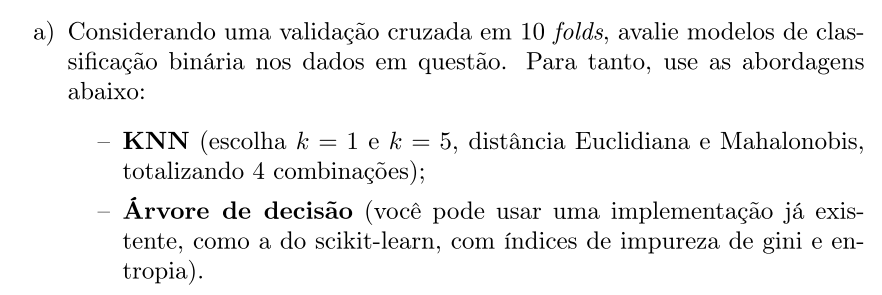

In [8]:
def knn_predict(X_train, y_train, X_test, k=3, metric='euclidean'):

    preds = []

    if metric == 'mahalanobis':
        inv_cov = mahalanobis_prepare(X_train)

    for x in X_test:

        distances = []

        for i in range(len(X_train)):

            if metric == 'euclidean':
                dist = euclidean(x, X_train[i])
            else:
                dist = mahalanobis(x, X_train[i], inv_cov)

            distances.append((dist, y_train[i]))

        distances.sort(key=lambda z: z[0])

        neighbors = distances[:k]
        labels = [item[1] for item in neighbors]

        pred = 1 if np.mean(labels) >= 0.5 else 0
        preds.append(pred)

    return np.array(preds)

In [9]:
# Métricas

def compute_metrics(y_true, y_pred):

    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    acc = (tp + tn) / (tp + tn + fp + fn)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0

    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return acc, precision, recall, f1

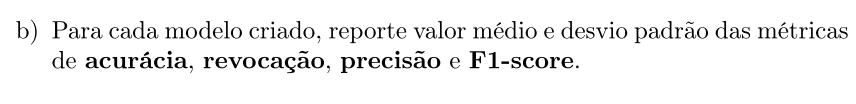

In [10]:
def summarize(results):

    for model in results:

        arr = np.array(results[model])

        mean = np.mean(arr, axis=0)
        std  = np.std(arr, axis=0)

        print("=" * 50)
        print(model)
        print("=" * 50)

        print(f"Acurácia : {mean[0]:.4f} ± {std[0]:.4f}")
        print(f"Precisão : {mean[1]:.4f} ± {std[1]:.4f}")
        print(f"Recall   : {mean[2]:.4f} ± {std[2]:.4f}")
        print(f"F1-score : {mean[3]:.4f} ± {std[3]:.4f}")
        print()

In [11]:
# Exec

np.random.seed(42)

folds = k_fold_split(X, y, 10)

results = {
    "knn_k1_euclidean": [],
    "knn_k5_euclidean": [],
    "knn_k1_mahalanobis": [],
    "knn_k5_mahalanobis": [],
    "tree_gini": [],
    "tree_entropy": []
}

for train_idx, test_idx in folds:

    X_train = X[train_idx]
    X_test  = X[test_idx]

    y_train = y[train_idx]
    y_test  = y[test_idx]

    # normalização
    X_train, X_test = normalize(X_train, X_test)

    # K-NN

    configs = [
        ("knn_k1_euclidean", 1, 'euclidean'),
        ("knn_k5_euclidean", 5, 'euclidean'),
        ("knn_k1_mahalanobis", 1, 'mahalanobis'),
        ("knn_k5_mahalanobis", 5, 'mahalanobis')
    ]

    for name, k, metric in configs:

        pred = knn_predict(X_train, y_train, X_test, k, metric)

        metrics = compute_metrics(y_test, pred)

        results[name].append(metrics)

    # Gini Tree

    tree = DecisionTreeClassifier(
        criterion='gini',
        random_state=42
    )

    tree.fit(X_train, y_train)

    pred = tree.predict(X_test)

    metrics = compute_metrics(y_test, pred)

    results["tree_gini"].append(metrics)

    # Entropy Tree

    tree = DecisionTreeClassifier(
        criterion='entropy',
        random_state=42
    )

    tree.fit(X_train, y_train)

    pred = tree.predict(X_test)

    metrics = compute_metrics(y_test, pred)

    results["tree_entropy"].append(metrics)

In [12]:
summarize(results)

knn_k1_euclidean
Acurácia : 0.7524 ± 0.1393
Precisão : 0.7886 ± 0.1602
Recall   : 0.7451 ± 0.1587
F1-score : 0.7543 ± 0.1222

knn_k5_euclidean
Acurácia : 0.7762 ± 0.1314
Precisão : 0.7939 ± 0.1420
Recall   : 0.7606 ± 0.1670
F1-score : 0.7701 ± 0.1348

knn_k1_mahalanobis
Acurácia : 0.6952 ± 0.0957
Precisão : 0.7339 ± 0.1384
Recall   : 0.6481 ± 0.1199
F1-score : 0.6791 ± 0.0992

knn_k5_mahalanobis
Acurácia : 0.7571 ± 0.1095
Precisão : 0.8012 ± 0.1019
Recall   : 0.6954 ± 0.1452
F1-score : 0.7387 ± 0.1200

tree_gini
Acurácia : 0.7143 ± 0.1065
Precisão : 0.7462 ± 0.1363
Recall   : 0.6615 ± 0.1399
F1-score : 0.6940 ± 0.1175

tree_entropy
Acurácia : 0.7095 ± 0.0837
Precisão : 0.7481 ± 0.1166
Recall   : 0.6915 ± 0.1208
F1-score : 0.7047 ± 0.0721



# ***EXTRAS***

# **Comparando Métricas Graficamente**

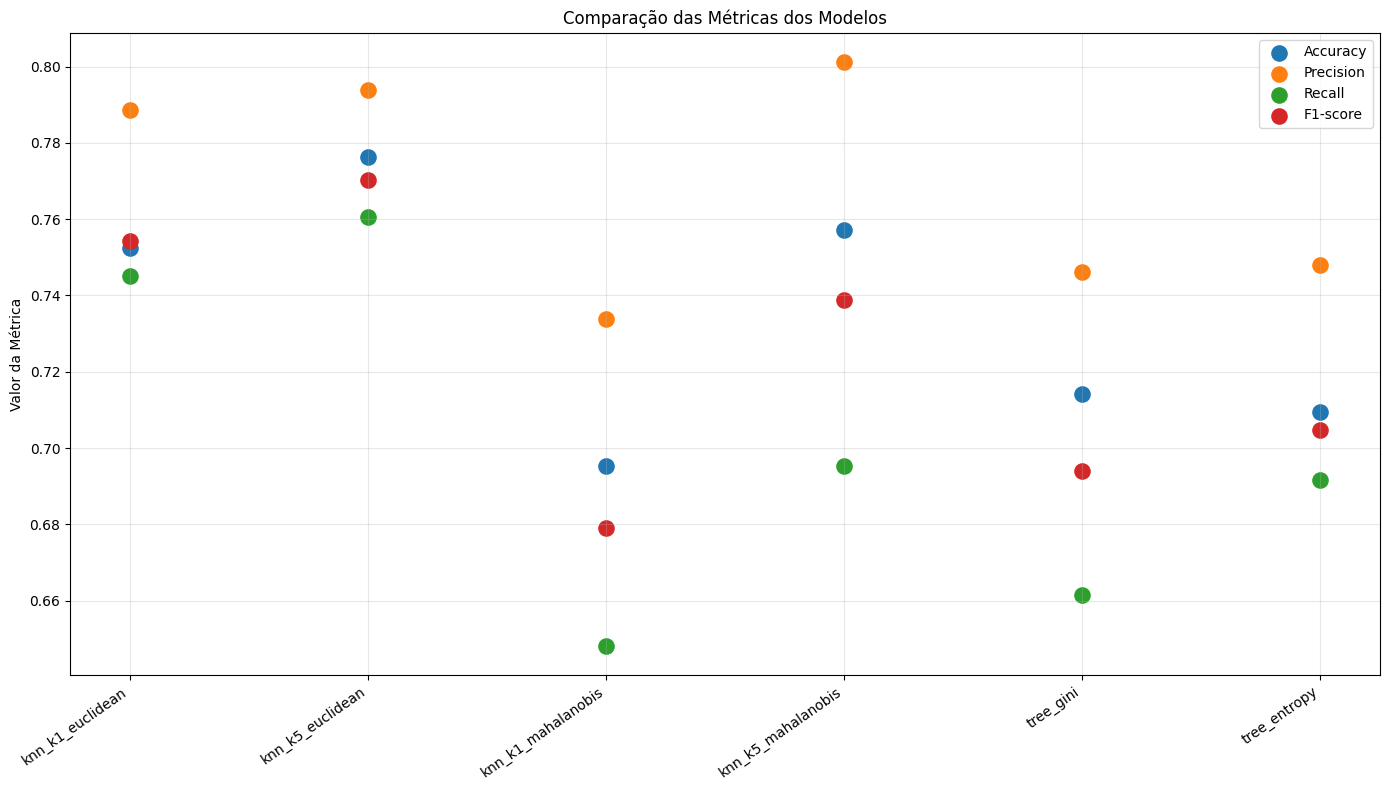

In [13]:
import matplotlib.pyplot as plt

models = list(results.keys())

# médias
acc = []
prec = []
rec = []
f1 = []

for model in models:

    arr = np.array(results[model])
    media = np.mean(arr, axis=0)

    acc.append(media[0])
    prec.append(media[1])
    rec.append(media[2])
    f1.append(media[3])

x = np.arange(len(models))

plt.figure(figsize=(14,8))

plt.scatter(x, acc,  s=120, label='Accuracy')
plt.scatter(x, prec, s=120, label='Precision')
plt.scatter(x, rec,  s=120, label='Recall')
plt.scatter(x, f1,   s=120, label='F1-score')

plt.xticks(x, models, rotation=35, ha='right')
plt.ylabel("Valor da Métrica")
plt.title("Comparação das Métricas dos Modelos")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# **RMSE**

In [14]:
def rmse(y_true, y_pred):

    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)

    return np.sqrt(np.mean((y_true - y_pred) ** 2))

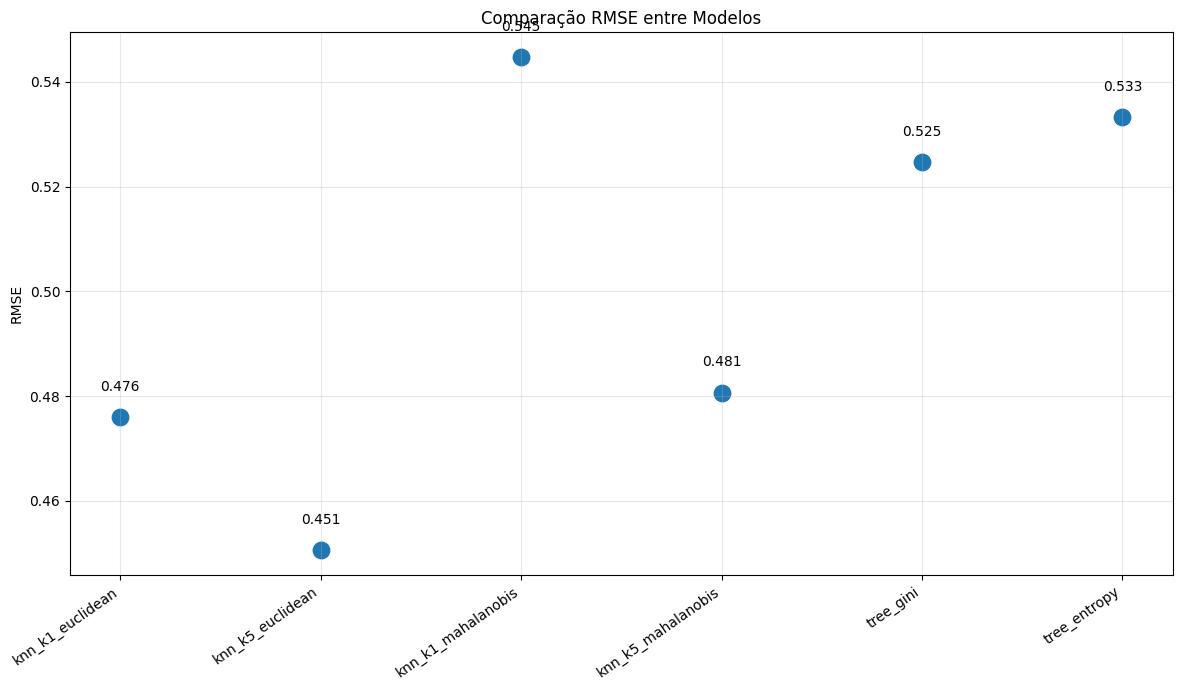

In [15]:
models = list(results.keys())
rmse_values = []

for model in models:

    folds_metrics = results[model]

    vals = []

    for fold in folds_metrics:
        acc = fold[0]

        # aproximação erro = 1-acc
        vals.append(np.sqrt(1 - acc))

    rmse_values.append(np.mean(vals))

x = np.arange(len(models))

plt.figure(figsize=(12,7))

plt.scatter(x, rmse_values, s=140)

for i, v in enumerate(rmse_values):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center')

plt.xticks(x, models, rotation=35, ha='right')
plt.ylabel("RMSE")
plt.title("Comparação RMSE entre Modelos")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()